## 1. Load data

In [117]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/Cars.csv")

## 2. EDA

### Explore

In [118]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [120]:
for col in df.columns:
    if df[col].dtype == "str":
        print(f"{col} ({df[col].nunique()}): {df[col].unique().tolist()[:10]}")
    else:
        min = df[col].min()
        max = df[col].max()
        print(f"{col}: {min} - {max}")

name (2058): ['Maruti Swift Dzire VDI', 'Skoda Rapid 1.5 TDI Ambition', 'Honda City 2017-2020 EXi', 'Hyundai i20 Sportz Diesel', 'Maruti Swift VXI BSIII', 'Hyundai Xcent 1.2 VTVT E Plus', 'Maruti Wagon R LXI DUO BSIII', 'Maruti 800 DX BSII', 'Toyota Etios VXD', 'Ford Figo Diesel Celebration Edition']
year: 1983 - 2020
selling_price: 29999 - 10000000
km_driven: 1 - 2360457
fuel (4): ['Diesel', 'Petrol', 'LPG', 'CNG']
seller_type (3): ['Individual', 'Dealer', 'Trustmark Dealer']
transmission (2): ['Manual', 'Automatic']
owner (5): ['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner', 'Test Drive Car']
mileage (393): ['23.4 kmpl', '21.14 kmpl', '17.7 kmpl', '23.0 kmpl', '16.1 kmpl', '20.14 kmpl', '17.3 km/kg', '23.59 kmpl', '20.0 kmpl', '19.01 kmpl']
engine (121): ['1248 CC', '1498 CC', '1497 CC', '1396 CC', '1298 CC', '1197 CC', '1061 CC', '796 CC', '1364 CC', '1399 CC']
max_power (322): ['74 bhp', '103.52 bhp', '78 bhp', '90 bhp', '88.2 bhp', '81.86 bhp', '57.5 bhp', '3

#### owner

In [121]:
owner_map = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5,
}
df["owner"] = df["owner"].map(owner_map)
df["owner"].head()

0    1
1    2
2    3
3    1
4    1
Name: owner, dtype: int64

#### fuel

In [122]:
df = df[~df["fuel"].isin(["LPG", "CNG"])]
df["fuel"].unique()

<StringArray>
['Diesel', 'Petrol']
Length: 2, dtype: str

#### mileage

In [123]:
df["mileage"] = df["mileage"].str.split(" ").str[0]
df["mileage"] = pd.to_numeric(df["mileage"], errors="coerce")
df["mileage"].head()

0    23.40
1    21.14
2    17.70
3    23.00
4    16.10
Name: mileage, dtype: float64

#### engine

In [124]:
df["engine"] = df["engine"].str.split(" ").str[0]
df["engine"] = pd.to_numeric(df["engine"], errors="coerce")
df["engine"].head()

0    1248.0
1    1498.0
2    1497.0
3    1396.0
4    1298.0
Name: engine, dtype: float64

#### max power

In [125]:
df["max_power"] = df["max_power"].str.split(" ").str[0]
df["max_power"] = pd.to_numeric(df["max_power"], errors="coerce")
df["max_power"].head()

0     74.00
1    103.52
2     78.00
3     90.00
4     88.20
Name: max_power, dtype: float64

#### name

In [126]:
df["name"] = df["name"].str.split(" ").str[0].astype(str)

df["name"].head()

0     Maruti
1      Skoda
2      Honda
3    Hyundai
4     Maruti
Name: name, dtype: str

#### torque

In [127]:
df = df.drop(columns=["torque"])
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats'],
      dtype='str')

#### drop Test Drive Cars

In [128]:
df = df[df["owner"] != 5]
df["owner"].unique()

array([1, 2, 3, 4])

### Explore again after EDA

In [129]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


In [130]:
df.info()

<class 'pandas.DataFrame'>
Index: 8028 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8028 non-null   str    
 1   year           8028 non-null   int64  
 2   selling_price  8028 non-null   int64  
 3   km_driven      8028 non-null   int64  
 4   fuel           8028 non-null   str    
 5   seller_type    8028 non-null   str    
 6   transmission   8028 non-null   str    
 7   owner          8028 non-null   int64  
 8   mileage        7814 non-null   float64
 9   engine         7814 non-null   float64
 10  max_power      7820 non-null   float64
 11  seats          7814 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 815.3 KB


In [131]:
for col in df.columns:
    if df[col].dtype == "str":
        print(f"{col} ({df[col].nunique()}): {df[col].unique().tolist()[:10]}")
    else:
        min = df[col].min()
        max = df[col].max()
        print(f"{col}: {min} - {max}")

name (32): ['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault', 'Mahindra', 'Tata', 'Chevrolet']
year: 1983 - 2020
selling_price: 29999 - 10000000
km_driven: 1000 - 2360457
fuel (2): ['Diesel', 'Petrol']
seller_type (3): ['Individual', 'Dealer', 'Trustmark Dealer']
transmission (2): ['Manual', 'Automatic']
owner: 1 - 4
mileage: 0.0 - 42.0
engine: 624.0 - 3604.0
max_power: 0.0 - 400.0
seats: 2.0 - 14.0


## 3. Feature selection

### Encoding categorical data

#### Label encoding

In [132]:
label_encoding_df = df.copy()

In [133]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

label_encoding_df["name"] = le.fit_transform(df["name"])
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

{'Ambassador': 0, 'Ashok': 1, 'Audi': 2, 'BMW': 3, 'Chevrolet': 4, 'Daewoo': 5, 'Datsun': 6, 'Fiat': 7, 'Force': 8, 'Ford': 9, 'Honda': 10, 'Hyundai': 11, 'Isuzu': 12, 'Jaguar': 13, 'Jeep': 14, 'Kia': 15, 'Land': 16, 'Lexus': 17, 'MG': 18, 'Mahindra': 19, 'Maruti': 20, 'Mercedes-Benz': 21, 'Mitsubishi': 22, 'Nissan': 23, 'Opel': 24, 'Peugeot': 25, 'Renault': 26, 'Skoda': 27, 'Tata': 28, 'Toyota': 29, 'Volkswagen': 30, 'Volvo': 31}


In [134]:
label_encoding_df["fuel"] = le.fit_transform(df["fuel"])
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

{'Diesel': 0, 'Petrol': 1}


In [135]:
label_encoding_df["seller_type"] = le.fit_transform(df["seller_type"])
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

{'Dealer': 0, 'Individual': 1, 'Trustmark Dealer': 2}


In [136]:
label_encoding_df["transmission"] = le.fit_transform(df["transmission"])
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

{'Automatic': 0, 'Manual': 1}


<Axes: >

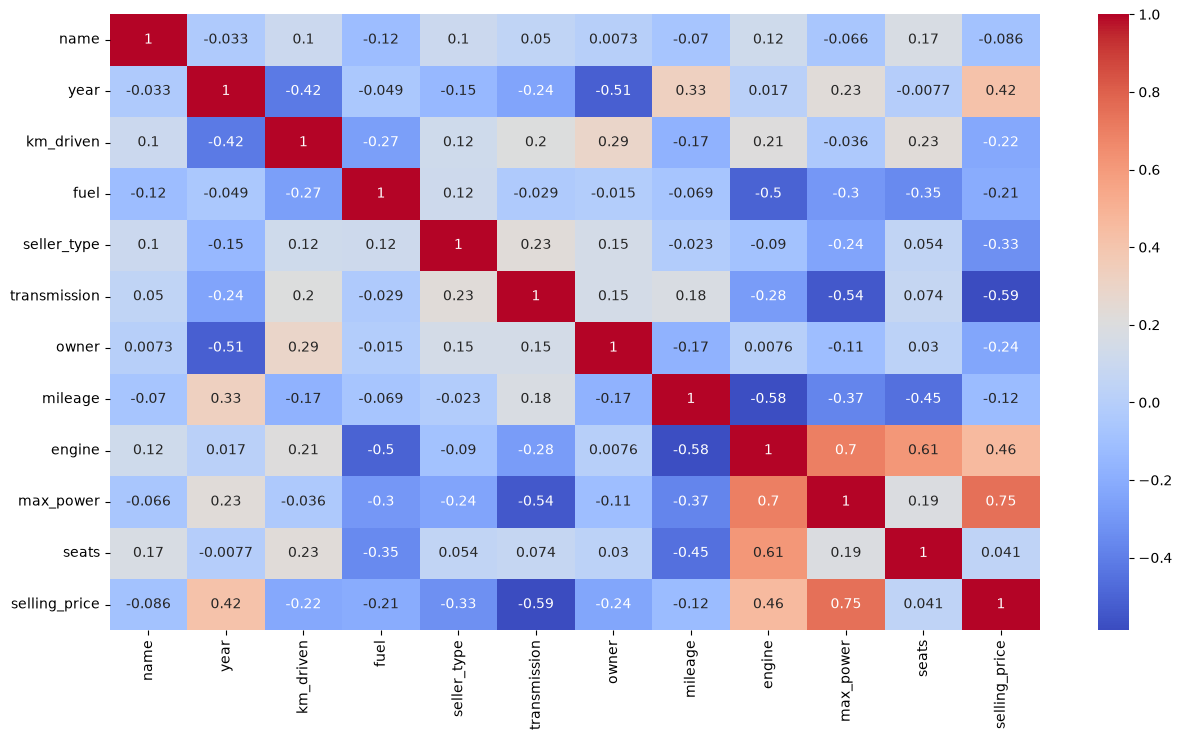

In [137]:
label_encoding_df['selling_price'] = label_encoding_df.pop('selling_price')

plt.figure(figsize=(15, 8))
sns.heatmap(label_encoding_df.corr(), annot=True, cmap="coolwarm")

#### One-hot encoding

In [138]:
one_hot_encoding_df = df.copy()

In [139]:
one_hot_encoding_df = pd.get_dummies(df, columns=["name", "fuel", "seller_type", "transmission"], dtype=int)

one_hot_encoding_df['selling_price'] = one_hot_encoding_df.pop('selling_price')
one_hot_encoding_df.columns

Index(['year', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats',
       'name_Ambassador', 'name_Ashok', 'name_Audi', 'name_BMW',
       'name_Chevrolet', 'name_Daewoo', 'name_Datsun', 'name_Fiat',
       'name_Force', 'name_Ford', 'name_Honda', 'name_Hyundai', 'name_Isuzu',
       'name_Jaguar', 'name_Jeep', 'name_Kia', 'name_Land', 'name_Lexus',
       'name_MG', 'name_Mahindra', 'name_Maruti', 'name_Mercedes-Benz',
       'name_Mitsubishi', 'name_Nissan', 'name_Opel', 'name_Peugeot',
       'name_Renault', 'name_Skoda', 'name_Tata', 'name_Toyota',
       'name_Volkswagen', 'name_Volvo', 'fuel_Diesel', 'fuel_Petrol',
       'seller_type_Dealer', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'transmission_Automatic',
       'transmission_Manual', 'selling_price'],
      dtype='str')

<Axes: >

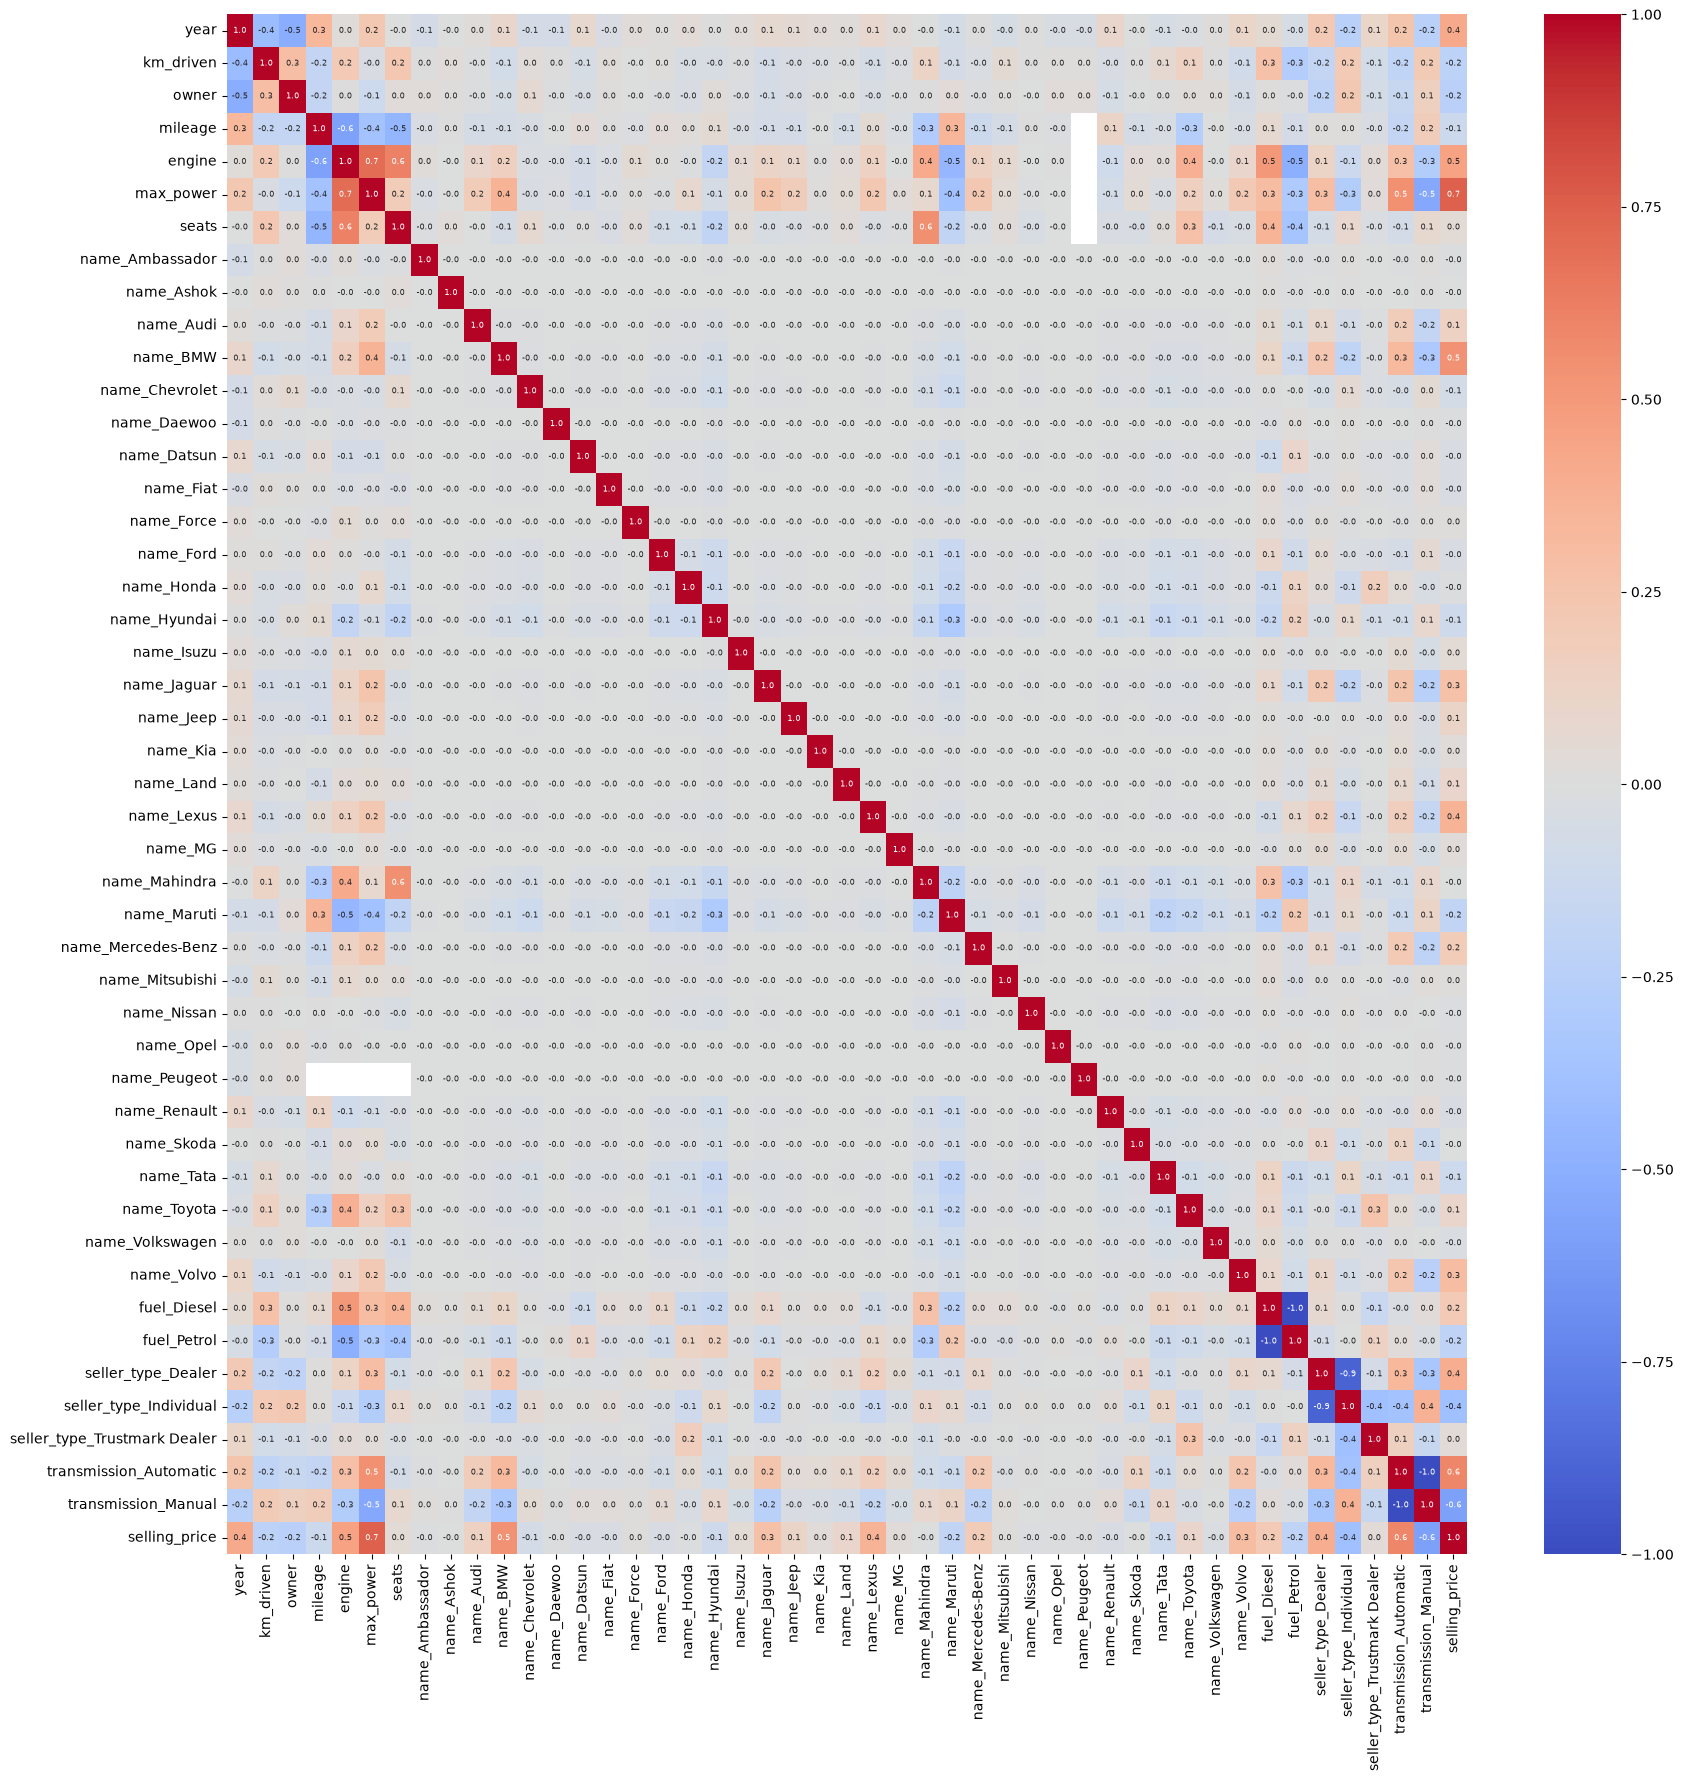

In [140]:
plt.figure(figsize=(20, 20))
# sns.heatmap(one_hot_encoding_df.corr(), annot=True, cmap="coolwarm")
sns.heatmap(one_hot_encoding_df.corr(), annot=True, fmt=".1f", annot_kws={"size": 6}, cmap="coolwarm")

<Axes: >

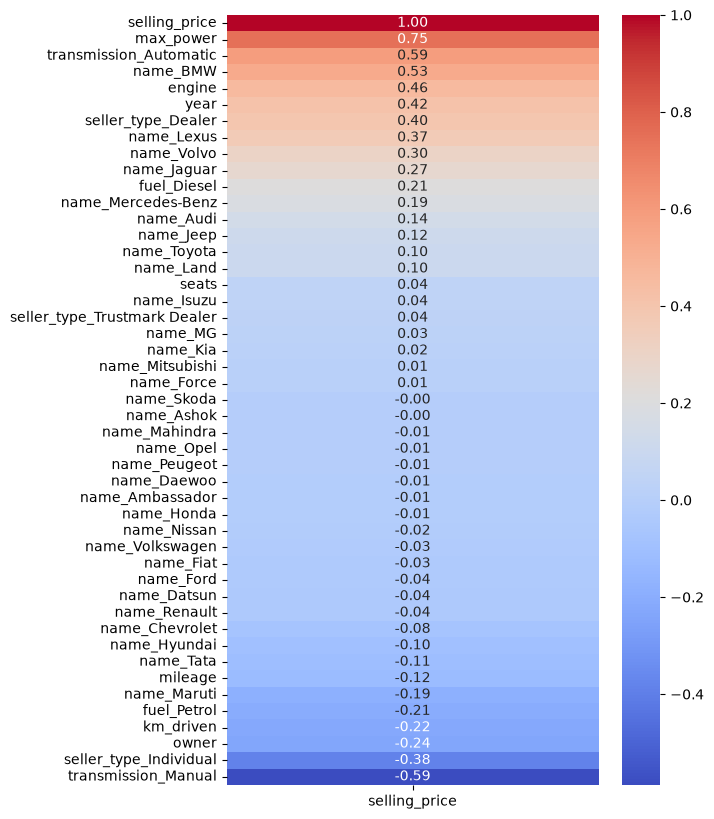

In [141]:
target_corr = one_hot_encoding_df.corr()[["selling_price"]].sort_values(by="selling_price", ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(target_corr, annot=True, cmap="coolwarm", fmt=".2f")

### choose the most salient X

In [145]:
selected_features = ["max_power", "transmission_Automatic", "name_BMW", "year", "seller_type_Dealer", "name_Lexus", "name_Volvo", "name_Jaguar"]

X = one_hot_encoding_df[selected_features]

### Specify the y

In [146]:
# y = df['selling_price']
y = np.log(df['selling_price'])

### Splitting

In [147]:
from sklearn.model_selection import train_test_split

random_state = 42
test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size, random_state = random_state)

In [148]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(6422, 8) (1606, 8)
(6422,) (1606,)


## 4. Preprocessing

### checking null values

In [149]:
print(y.isna().sum())

0


In [150]:
for col in X_train.columns:
    print(col, X_train[col].isna().sum())

max_power 165
transmission_Automatic 0
name_BMW 0
year 0
seller_type_Dealer 0
name_Lexus 0
name_Volvo 0
name_Jaguar 0


### checking distribution of each features

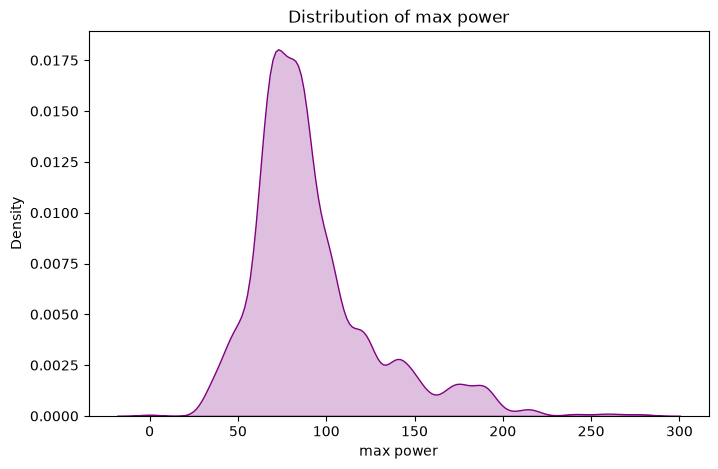

In [151]:
plt.figure(figsize=(8, 5))
sns.kdeplot(X_train["max_power"], fill=True, color='purple')
plt.title("Distribution of max power")
plt.xlabel("max power")
plt.show()

### checking outliers

In [156]:
def outlier_count(col, data = X_train):
    
    # calculate your 25% quatile and 75% quatile
    q75, q25 = np.percentile(data[col], [75, 25])
    
    # calculate your inter quatile
    iqr = q75 - q25
    
    # min_val and max_val
    min_val = q25 - (iqr*1.5)
    max_val = q75 + (iqr*1.5)
    
    # count number of outliers, which are the data that are less than min_val or more than max_val calculated above
    outlier_count = len(np.where((data[col] > max_val) | (data[col] < min_val))[0])
    
    # calculate the percentage of the outliers
    outlier_percent = round(outlier_count/len(data[col])*100, 2)
    
    # if(outlier_count > 0):
    print("\n"+15*'-' + col + 15*'-'+"\n")
    print('Number of outliers: {}'.format(outlier_count))
    print('Percent of data that is outlier: {}%'.format(outlier_percent))

In [157]:
for col in X_train.columns:
    outlier_count(col)


---------------max_power---------------

Number of outliers: 0
Percent of data that is outlier: 0.0%

---------------transmission_Automatic---------------

Number of outliers: 849
Percent of data that is outlier: 13.22%

---------------name_BMW---------------

Number of outliers: 90
Percent of data that is outlier: 1.4%

---------------year---------------

Number of outliers: 63
Percent of data that is outlier: 0.98%

---------------seller_type_Dealer---------------

Number of outliers: 891
Percent of data that is outlier: 13.87%

---------------name_Lexus---------------

Number of outliers: 28
Percent of data that is outlier: 0.44%

---------------name_Volvo---------------

Number of outliers: 58
Percent of data that is outlier: 0.9%

---------------name_Jaguar---------------

Number of outliers: 55
Percent of data that is outlier: 0.86%


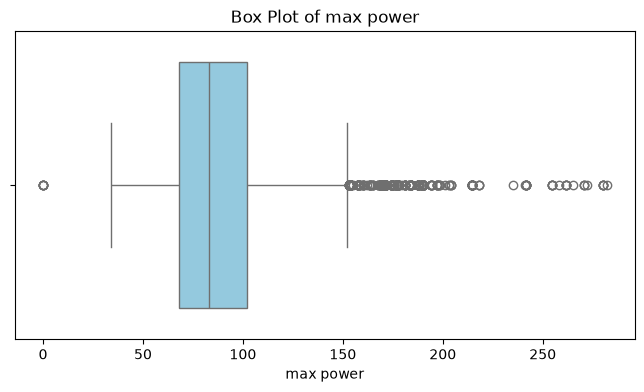

In [154]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=X_train['max_power'], color='skyblue')
plt.title("Box Plot of max power")
plt.xlabel("max power")
plt.show()

### Replacing NaN (null with median)

In [158]:
median_max_power = X_train["max_power"].median()

X_train["max_power"] = X_train["max_power"].fillna(median_max_power)
X_test["max_power"] = X_test["max_power"].fillna(median_max_power)

## 5. Model selection

In [159]:
from sklearn.linear_model import LinearRegression  #we are using regression models
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Libraries for model evaluation

# models that we will be using, put them in a list
algorithms = [LinearRegression(), SVR(), KNeighborsRegressor(), DecisionTreeRegressor(random_state = 0), 
              RandomForestRegressor(n_estimators = 100, random_state = 0)]

# The names of the models
algorithm_names = ["Linear Regression", "SVR", "KNeighbors Regressor", "Decision-Tree Regressor", "Random-Forest Regressor"]

In [160]:
from sklearn.model_selection import KFold, cross_val_score

#lists for keeping mse
train_mse = []
test_mse = []

#defining splits
n_splits = 10
kfold = KFold(n_splits=n_splits, shuffle=True)

for i, model in enumerate(algorithms):
    scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2')
    print(f"{algorithm_names[i]} - Score: {scores}; Mean: {scores.mean()}")

Linear Regression - Score: [0.82062643 0.84341397 0.81157523 0.85210163 0.82848088 0.80687327
 0.86250432 0.8507637  0.84799753 0.84337049]; Mean: 0.8367707467873237
SVR - Score: [0.52191645 0.56603808 0.55308237 0.51124599 0.45924145 0.57598929
 0.48619817 0.50879705 0.46826853 0.53379011]; Mean: 0.5184567508871597
KNeighbors Regressor - Score: [0.88351362 0.90053221 0.88473862 0.88716874 0.89027462 0.90745123
 0.88355848 0.90881059 0.88559892 0.89161953]; Mean: 0.8923266555292082
Decision-Tree Regressor - Score: [0.9000224  0.91612396 0.88589825 0.89774157 0.91018024 0.89662578
 0.88832393 0.86987603 0.88449031 0.89568435]; Mean: 0.8944966808172955
Random-Forest Regressor - Score: [0.89856243 0.89248974 0.92071498 0.92642362 0.89840814 0.89976194
 0.89924282 0.92656286 0.90189798 0.90030991]; Mean: 0.9064374411107092


### Grid search (RF)

In [161]:
from sklearn.model_selection import GridSearchCV

param_grid = {'bootstrap': [True], 'max_depth': [5, 10, None],
              'n_estimators': [5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 50, 100, 200]}

rf = RandomForestRegressor(random_state = 1)

grid = GridSearchCV(estimator = rf, 
                    param_grid = param_grid, 
                    cv = kfold, 
                    n_jobs = -1, 
                    return_train_score=True, 
                    refit=True,
                    scoring='r2')

# Fit your grid_search
grid.fit(X_train, y_train);

In [162]:
grid.best_params_

{'bootstrap': True, 'max_depth': 10, 'n_estimators': 200}

In [163]:
best_mse = grid.best_score_
best_mse

np.float64(0.9058177375735678)

## 6. Testing

In [164]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = grid.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 0.061715844590836004
R2: 0.9133376522792575


## 7. Analysis (Feature Importance)

In [165]:
rf = grid.best_estimator_
rf.feature_importances_

array([5.02804497e-01, 2.76374718e-03, 1.58053421e-03, 4.89020205e-01,
       2.16542819e-03, 4.92705724e-07, 3.39884495e-04, 1.32521135e-03])

Text(0.5, 0, 'Random Forest Feature Importance')

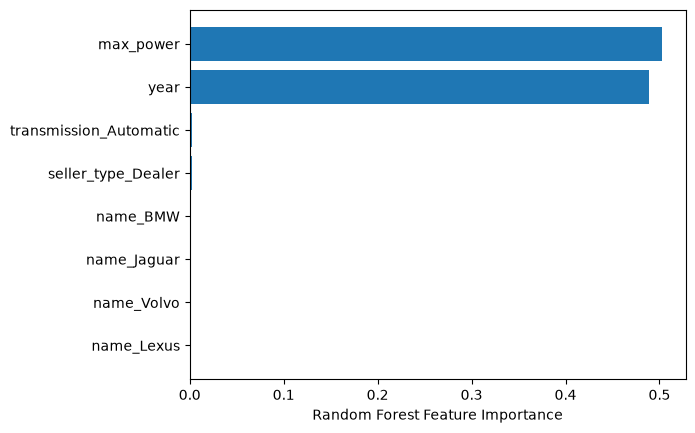

In [166]:
sorted_idx = rf.feature_importances_.argsort()
plt.barh(X.columns[sorted_idx], rf.feature_importances_[sorted_idx])
plt.xlabel("Random Forest Feature Importance")

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

                  feature    importance           std
0               max_power  7.371421e-01  2.258814e-02
3                    year  6.805397e-01  2.160884e-02
1  transmission_Automatic  4.889898e-03  5.121712e-04
2                name_BMW  3.216609e-03  9.888658e-04
4      seller_type_Dealer  1.407946e-03  3.200980e-04
7             name_Jaguar  9.332851e-04  2.082289e-04
5              name_Lexus  1.598294e-07  9.572254e-09
6              name_Volvo -1.169095e-04  1.033304e-07


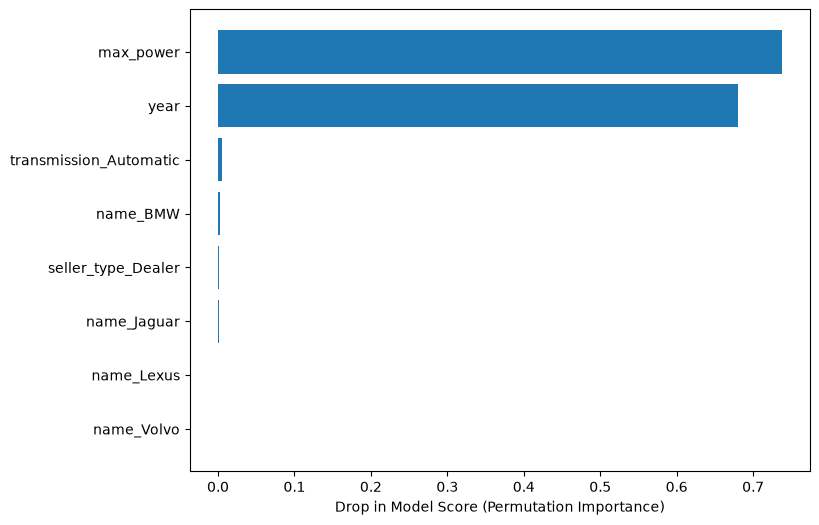

In [169]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. แปลงเป็น DataFrame เพื่อดูตัวเลขชัดๆ
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values(by='importance', ascending=False)

print(perm_df)

# 2. พล็อตเป็นกราฟแท่ง
plt.figure(figsize=(8, 6))
plt.barh(perm_df['feature'], perm_df['importance'])
plt.gca().invert_yaxis() # เรียงจากมากไปน้อย
plt.xlabel("Drop in Model Score (Permutation Importance)")
plt.show()

### Final model

In [191]:
X_train_final = X_train[["max_power", "year"]].copy()
X_test_final = X_test[["max_power", "year"]].copy()

In [192]:
best_params = grid.best_params_

test_size = 0.2

final_model = RandomForestRegressor(**best_params, random_state=42)
final_model.fit(X_train_final, y_train)

y_pred = final_model.predict(X_test_final)
print("Test R2 Score:", r2_score(y_test, y_pred))
print("Test MSE Score:", mean_squared_error(y_test, y_pred))

Test R2 Score: 0.9111890465173966
Test MSE Score: 0.06324595568029401


### Save Model

In [193]:
import joblib

filename = "model/car_price_model.pkl"
joblib.dump(final_model, filename)

['model/car_price_model.pkl']

## 8. Inference

In [ ]:
loaded_model = joblib.load(open(filename, "rb"))

In [204]:
df[["max_power", "year", "selling_price"]].iloc[:5]

,max_power,year,selling_price
0,74.00,2014,450000
1,103.52,2014,370000
2,78.00,2006,158000
3,90.00,2010,225000
4,88.20,2007,130000


In [205]:
samples = df[["max_power", "year"]].iloc[:5].copy()
samples

,max_power,year
0,74.00,2014
1,103.52,2014
2,78.00,2006
3,90.00,2010
4,88.20,2007


### no scale (the output)

In [206]:
no_scale_predicted_cost = loaded_model.predict(samples)
no_scale_predicted_cost

array([13.03227166, 13.06613651, 11.95418049, 12.29940068, 12.07000824])

### scale (the output)

In [207]:
scale_predicted_cost = np.exp(loaded_model.predict(samples))
scale_predicted_cost

array([456923.6849003 , 472662.32190656, 155465.71220474, 219564.35993217,
       174557.28441985])

## Report

### • Which features are important? Which are not? Why?

###  • Which algorithm performs well? Which does not? Why?